In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
    print("Uploaded files in Colab environment")
except ImportError:
    uploaded = {}
    print("Not running in Google Colab; using the local dataset.csv file")


Not running in Google Colab; using the local dataset.csv file


In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
df.shape

(2000, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [6]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [7]:
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [8]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

X = df.drop('price_range', axis=1)
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale'),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name}: {acc:.4f}')

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f'Best Model: {best_model_name} with accuracy {results[best_model_name]:.4f}')

C:\Users\LENOVO\OneDrive\Documents\Mobile Price Prediction\mobile-price-prediction-ml\.venv311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 0.7575
Decision Tree: 0.8325


Random Forest: 0.8925


Extra Trees: 0.8725
SVM: 0.9675


KNN: 0.9275


Gradient Boosting: 0.9050
Best Model: SVM with accuracy 0.9675


In [11]:
# Final model training and evaluation for the chosen best model
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_best)
print('Final Model Accuracy:', round(accuracy, 4))
print(classification_report(y_test, y_pred_best))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_best))

Final Model Accuracy: 0.9675
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       105
           1       0.95      1.00      0.97        91
           2       0.96      0.92      0.94        92
           3       0.96      0.96      0.96       112

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400

Confusion Matrix:
[[103   2   0   0]
 [  0  91   0   0]
 [  0   3  85   4]
 [  0   0   4 108]]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.905


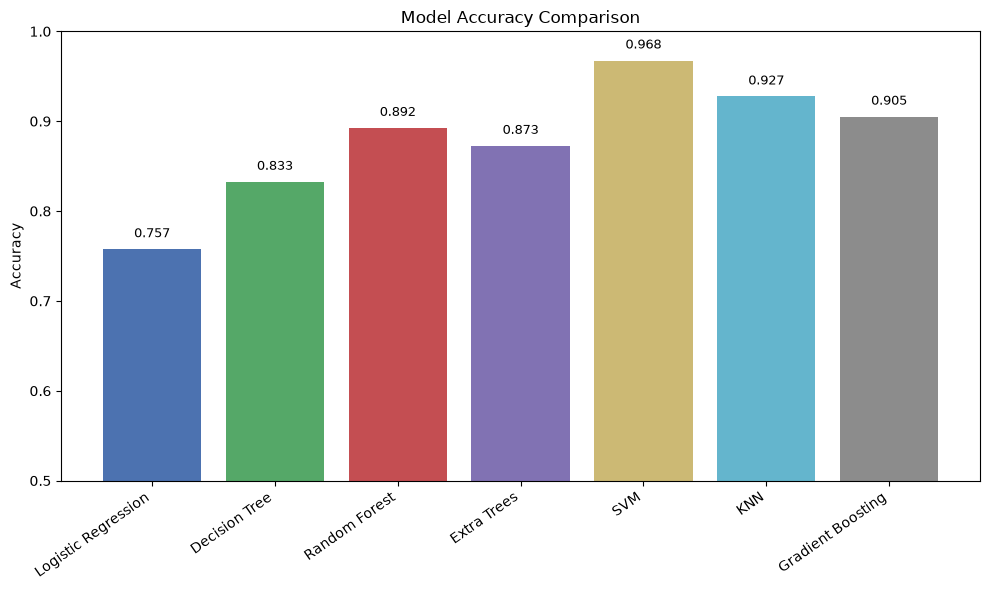


Code by Naga Sai
Final selected model: SVM
Final accuracy: 0.9675


In [13]:
# Visual model comparison
model_names = list(results.keys())
model_scores = list(results.values())

plt.figure(figsize=(10, 6))
plt.bar(model_names, model_scores, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD', '#8C8C8C'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=35, ha='right')
plt.ylim(0.5, 1.0)
for i, v in enumerate(model_scores):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Feature importance for final model if supported
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = list(X.columns)
    indices = np.argsort(importances)[::-1][:10]
    plt.figure(figsize=(10, 6))
    plt.title('Top 10 Feature Importances')
    plt.bar(range(10), importances[indices], align='center')
    plt.xticks(range(10), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Final model representation summary
print('')
print('===========================================')
print('Code by Naga Sai')
print('Final selected model:', best_model_name)
print('Final accuracy:', round(results[best_model_name], 4))
print('===========================================')